# MODIS MAIAC AOD — Data Understanding for ALAPA-APP

**What this notebook is for.** In ALAPA-APP, satellite AOD (aerosol optical depth)
from MODIS MAIAC is a *covariate*: it tells the model how much aerosol is in the
air column over each 1 km cell, and the Land Use Regression uses it to help
estimate PM2.5/PM10 at 100 m. Before we can trust it, we need to answer five
simple questions:

1. **How much data do we actually have?** (files, dates, gaps)
2. **How often is AOD usable?** — the *valid-retrieval rate*, which §4.3.7 of the
   methodology says must be reported per month and by wet/dry season
3. **What do the values look like?** (typical range, seasonality)
4. **Where is the signal?** (does urban Manila stand out spatially — the reason
   downscaling is worth doing)
5. **Why do we lose pixels?** (cloud screening — the known MAIAC weakness)

Each file in `outputs/modis/` is one day's granule, clipped to the Metro Manila
AOI and QA-masked, with 4 bands (`NODATA = -9999`):

| Band | Name | Content |
|------|------|---------|
| 1 | `AOD_047` | AOD at 470 nm |
| 2 | `AOD_055` | AOD at 550 nm |
| 3 | `CWV` | Column water vapour (cm) |
| 4 | `QA` | QA bitmask |

The last cell prints a **fact sheet** with the numbers Table 4.1 marks
"to be confirmed".

In [1]:
import re
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

MODIS_DIR = Path("outputs/modis")
EDA_DIR = Path("outputs/eda"); EDA_DIR.mkdir(parents=True, exist_ok=True)
NODATA = -9999.0
BAND_ORDER = ["AOD_047", "AOD_055", "CWV", "QA"]
SCIENCE_BANDS = ["AOD_047", "AOD_055", "CWV"]
AOI_BOUNDS = [120.868835, 14.316284, 121.143494, 14.781522]  # W, S, E, N (same as modis.py)
DATE_RE = re.compile(r"MODIS_(\d{8})_")

# Philippine seasons used throughout (monsoon-based)
DRY_MONTHS = [12, 1, 2, 3, 4, 5]
WET_MONTHS = [6, 7, 8, 9, 10, 11]

# --- palette: fixed color per band ---
C = {
    "AOD_047": "#2a78d6",   # blue
    "AOD_055": "#1baf7a",   # aqua
    "CWV":     "#4a3aa7",   # violet
    "dry":     "#2a78d6",
    "wet":     "#1baf7a",
    "ink":     "#0b0b0b",
    "ink2":    "#52514e",
    "muted":   "#898781",
    "grid":    "#e1e0d9",
    "baseline": "#c3c2b7",
}
SEQ_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
SEQ_AQUA = LinearSegmentedColormap.from_list(
    "seq_aqua", ["#d8f3e9", "#8fdcbf", "#3fc394", "#1baf7a", "#12805a", "#0b5c40"])
DIV = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": C["baseline"],
    "axes.labelcolor": C["ink2"],
    "axes.titlecolor": C["ink"],
    "axes.grid": True,
    "grid.color": C["grid"],
    "grid.linewidth": 0.8,
    "xtick.color": C["muted"],
    "ytick.color": C["muted"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

## 1. Read every file once

One pass over all GeoTIFFs collects everything the rest of the notebook uses:
per-file stats, pooled pixel values, QA rejection counters, and each day's
AOD resampled onto a common ~1 km lat/lon grid (the files are trimmed to their
valid pixels, so their shapes all differ — they must be put on one grid before
any spatial averaging). Takes a minute or two.

In [2]:
files = sorted(MODIS_DIR.glob("*.tif"))
print(f"{len(files)} GeoTIFFs")

# common lat/lon grid (~1 km ~= 0.009 deg)
RES = 0.009
GW = int(np.ceil((AOI_BOUNDS[2] - AOI_BOUNDS[0]) / RES))
GH = int(np.ceil((AOI_BOUNDS[3] - AOI_BOUNDS[1]) / RES))
grid_transform = from_bounds(*AOI_BOUNDS, GW, GH)
aod_sum = np.zeros((12, GH, GW), dtype="float64")   # per calendar month
aod_cnt = np.zeros((12, GH, GW), dtype="int32")

rows, pools = [], {k: [] for k in SCIENCE_BANDS}
pair_x, pair_y = [], []
cwv_x, cwv_y = [], []
qa_counts = {"kept": 0, "adjacent cloud": 0, "cloudy": 0, "fill": 0}

for path in files:
    with rasterio.open(path) as src:
        arrs = {k: src.read(i).astype("float32") for i, k in enumerate(BAND_ORDER, 1)}
        src_transform, src_crs = src.transform, src.crs

    for k in SCIENCE_BANDS:
        arrs[k][arrs[k] == NODATA] = np.nan

    row = {"date": datetime.strptime(DATE_RE.search(path.name).group(1), "%Y%m%d"),
           "file": path.name, "total_px": arrs["AOD_047"].size}
    for k in SCIENCE_BANDS:
        v = arrs[k][~np.isnan(arrs[k])]
        row[f"{k}_valid_px"] = v.size
        row[f"{k}_valid_frac"] = v.size / row["total_px"]
        row[f"{k}_mean"] = float(v.mean()) if v.size else np.nan
        row[f"{k}_max"] = float(v.max()) if v.size else np.nan
        if v.size:
            pools[k].append(v)
    rows.append(row)

    m = ~np.isnan(arrs["AOD_047"]) & ~np.isnan(arrs["AOD_055"])
    pair_x.append(arrs["AOD_047"][m]); pair_y.append(arrs["AOD_055"][m])
    if row["CWV_valid_px"] and row["AOD_047_valid_px"]:
        cwv_x.append(row["CWV_mean"]); cwv_y.append(row["AOD_047_mean"])

    # QA categories over in-AOI pixels (same bit convention as modis.py:
    # bits 0-1 = cloud, bit 2 = adjacent cloud, 65535 = fill)
    qa = arrs["QA"][arrs["QA"] != NODATA].astype("uint16")
    fill = qa == 65535
    cloudy = ~fill & ((qa & 0b11) > 1)
    adjacent = ~fill & ~cloudy & ((qa & 0b100) != 0)
    qa_counts["fill"] += int(fill.sum())
    qa_counts["cloudy"] += int(cloudy.sum())
    qa_counts["adjacent cloud"] += int(adjacent.sum())
    qa_counts["kept"] += int((~fill & ~cloudy & ~adjacent).sum())

    # accumulate AOD_047 onto the common grid, per calendar month
    dst = np.full((GH, GW), np.nan, dtype="float32")
    reproject(np.nan_to_num(arrs["AOD_047"], nan=NODATA), dst,
              src_transform=src_transform, src_crs=src_crs,
              dst_transform=grid_transform, dst_crs="EPSG:4326",
              src_nodata=NODATA, dst_nodata=np.nan, resampling=Resampling.nearest)
    gm = ~np.isnan(dst)
    mi = row["date"].month - 1
    aod_sum[mi][gm] += dst[gm]; aod_cnt[mi][gm] += 1

df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
pools = {k: (np.concatenate(v) if v else np.array([], dtype="float32")) for k, v in pools.items()}
pair_x = np.concatenate(pair_x); pair_y = np.concatenate(pair_y)
df.to_csv(EDA_DIR / "modis_summary.csv", index=False)
print("scan done ->", EDA_DIR / "modis_summary.csv")

980 GeoTIFFs


scan done -> outputs\eda\modis_summary.csv


## 2. What we have

Simple inventory: how many granules were processed, over what period, and how
many days of the study window they cover. MCD19A2 is a *daily* product, so a
day without a file means either LAADS listed no granule for the tile that day
or the pipeline hasn't backfilled it yet — worth knowing before training.

In [3]:
start, end = df["date"].min(), df["date"].max()
all_days = pd.date_range(start, end, freq="D")
have_days = set(df["date"].dt.normalize())
empty = (df["AOD_047_valid_px"] == 0).sum()

print(f"Granules processed:      {len(df)}")
print(f"Date range:              {start:%Y-%m-%d} -> {end:%Y-%m-%d}  ({len(all_days)} days)")
print(f"Days with a granule:     {len(have_days)} ({len(have_days)/len(all_days):.0%} of the window)")
print(f"Granules with zero AOD:  {empty} ({empty/len(df):.1%}) - fully clouded out")
df[["AOD_047_mean", "AOD_055_mean", "CWV_mean"]].describe().round(3)

Granules processed:      980
Date range:              2021-07-12 -> 2026-07-08  (1823 days)
Days with a granule:     980 (54% of the window)
Granules with zero AOD:  36 (3.7%) - fully clouded out


,AOD_047_mean,AOD_055_mean,CWV_mean
count,944.000,944.000,964.000
mean,0.330,0.242,4.739
std,0.142,0.106,1.211
min,0.000,0.000,0.892
25%,0.230,0.168,4.025
50%,0.322,0.234,4.883
75%,0.431,0.317,5.687
max,1.137,0.842,6.897


## 3. How often is AOD usable? — the valid-retrieval rate

**This is the number §4.3.7 of the methodology promises to report.** For each
calendar month we compute: *of all cell-days (each 1 km cell x each day in the
study window), what fraction produced a usable AOD value after cloud/QA
screening?* Days with no granule count as misses, so this is the honest rate
the LUR fusion actually experiences — everything below the bar is a cell-day
where the pipeline **falls back to the kriged ground-sensor surface**.

Simple reading: tall bar = satellite helps often; short bar = mostly kriging.

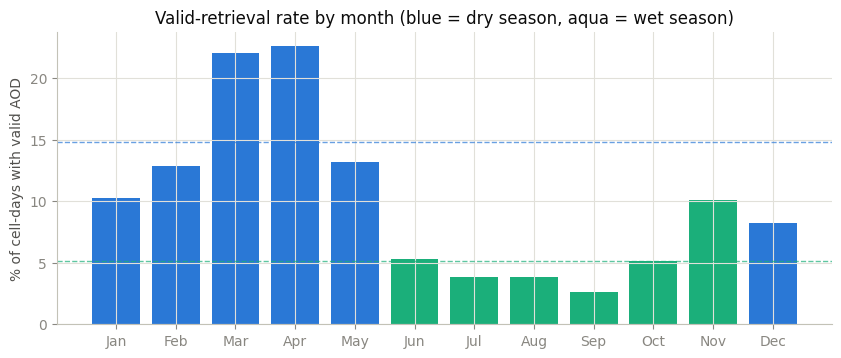

Overall:      10.0% of cell-days
Dry (Dec-May): 14.9%
Wet (Jun-Nov): 5.1%
-> the LUR->kriging fallback is invoked on ~90% of cell-days


In [4]:
days_per_month = pd.Series(all_days.month).value_counts().sort_index()  # days of each calendar month in the window

monthly_rate = np.array([aod_cnt[m].mean() / days_per_month[m + 1] * 100 for m in range(12)])

def season_rate(month_list):
    obs = sum(aod_cnt[m - 1].mean() for m in month_list)
    days = sum(days_per_month[m] for m in month_list)
    return obs / days * 100

dry_rate, wet_rate = season_rate(DRY_MONTHS), season_rate(WET_MONTHS)
overall_rate = aod_cnt.sum(axis=0).mean() / len(all_days) * 100

colors = [C["dry"] if (m + 1) in DRY_MONTHS else C["wet"] for m in range(12)]
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(MONTHS, monthly_rate, color=colors)
ax.axhline(dry_rate, color=C["dry"], lw=1, ls="--", alpha=0.7)
ax.axhline(wet_rate, color=C["wet"], lw=1, ls="--", alpha=0.7)
ax.set_ylabel("% of cell-days with valid AOD")
ax.set_title("Valid-retrieval rate by month (blue = dry season, aqua = wet season)")
plt.show()

print(f"Overall:      {overall_rate:.1f}% of cell-days")
print(f"Dry (Dec-May): {dry_rate:.1f}%")
print(f"Wet (Jun-Nov): {wet_rate:.1f}%")
print(f"-> the LUR->kriging fallback is invoked on ~{100 - overall_rate:.0f}% of cell-days")

## 4. How long are the blackouts?

The retrieval rate says *how much* is missing; this says *how it clusters*.
Counting only days where at least one pixel survived QA: the median gap between
usable days tells us the effective revisit, and the longest gap is the worst
stretch the fallback has to bridge alone. Long wet-season blackouts matter
because that is exactly when pollutant behaviour differs (rain scavenging), so
the missingness is **not random** — the thesis treats its effect on downscaling
quality as an empirical result.

Days with any valid AOD:  944 of 1823
Median gap:               1 day(s)
Gaps > 7 days:            19 (2.0%)
Longest gap:              17 days, ending 2025-07-29


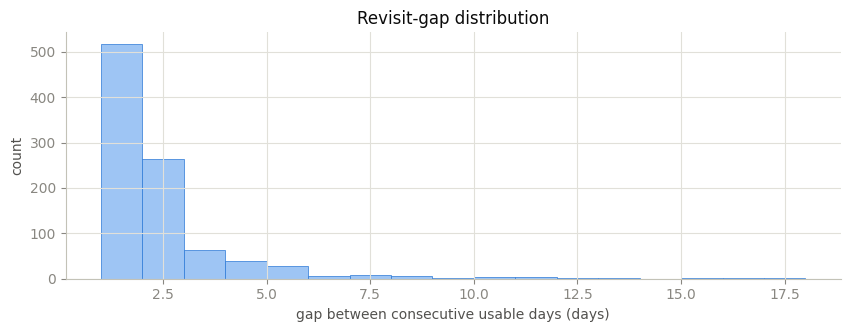

In [5]:
valid_dates = (df.loc[df["AOD_047_valid_px"] > 0, "date"]
                 .sort_values().drop_duplicates())
gaps = valid_dates.diff().dt.days.dropna()
worst_end = valid_dates.iloc[int(np.argmax(gaps.values)) + 1]

print(f"Days with any valid AOD:  {len(valid_dates)} of {len(all_days)}")
print(f"Median gap:               {gaps.median():.0f} day(s)")
print(f"Gaps > 7 days:            {(gaps > 7).sum()} ({(gaps > 7).mean():.1%})")
print(f"Longest gap:              {gaps.max():.0f} days, ending {worst_end:%Y-%m-%d}")

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.hist(gaps, bins=range(1, int(gaps.max()) + 2), color="#9ec5f4",
        edgecolor=C["AOD_047"], lw=0.5)
ax.set_xlabel("gap between consecutive usable days (days)")
ax.set_ylabel("count")
ax.set_title("Revisit-gap distribution")
plt.show()

## 5. What do the AOD values look like?

Left: every valid AOD_047 pixel pooled. Most values sit in the 0.1-0.6 range
(moderate urban aerosol); the long right tail is haze/burning episodes — the
events a health-oriented forecast must catch, and the reason the ground-sensor
cleaning avoids aggressive outlier filters. Right: the AOI-mean over time with
monthly means; a recurring seasonal swing here is the AOD side of the
seasonality the PM models will have to learn.

One consistency check: AOD_047 and AOD_055 come from the same retrieval and
should be almost perfectly correlated (r printed below). If that ever breaks,
something is wrong in the extraction, not the atmosphere.

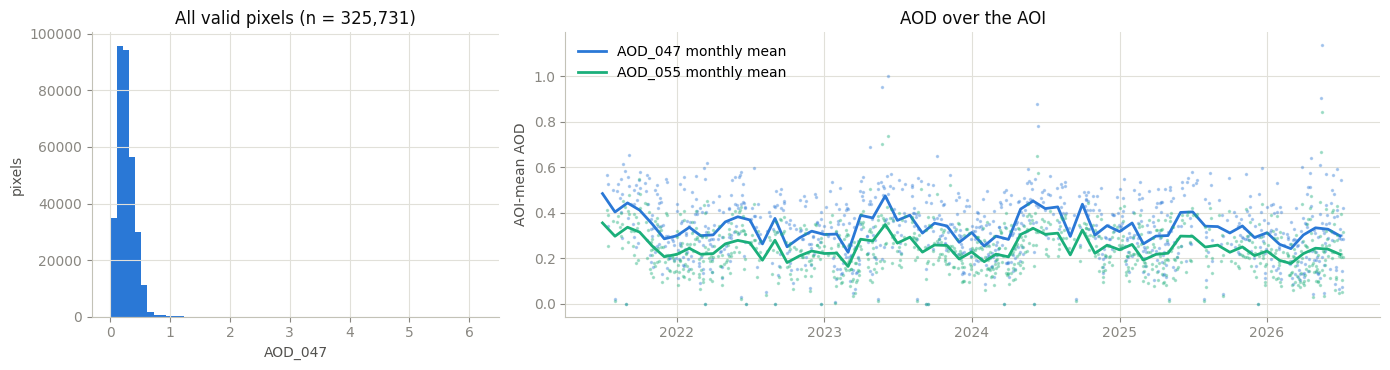

AOD_047 vs AOD_055 pixel correlation: r = 0.996  (should be ~1)
Pooled AOD_047: mean 0.258, median 0.237, p95 0.507


In [6]:
d = df[df["AOD_047_valid_px"] > 0].set_index("date")
monthly = d[["AOD_047_mean", "AOD_055_mean"]].resample("MS").mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3.8), width_ratios=[1, 2])
ax1.hist(pools["AOD_047"], bins=60, color=C["AOD_047"])
ax1.set_xlabel("AOD_047"); ax1.set_ylabel("pixels")
ax1.set_title(f"All valid pixels (n = {pools['AOD_047'].size:,})")

for k in ("AOD_047", "AOD_055"):
    ax2.plot(d.index, d[f"{k}_mean"], ".", ms=3, alpha=0.3, color=C[k])
    ax2.plot(monthly.index, monthly[f"{k}_mean"], "-", lw=2, color=C[k],
             label=f"{k} monthly mean")
ax2.set_ylabel("AOI-mean AOD")
ax2.set_title("AOD over the AOI")
ax2.legend(frameon=False)
plt.tight_layout(); plt.show()

r = np.corrcoef(pair_x, pair_y)[0, 1]
print(f"AOD_047 vs AOD_055 pixel correlation: r = {r:.3f}  (should be ~1)")
print(f"Pooled AOD_047: mean {pools['AOD_047'].mean():.3f}, "
      f"median {np.median(pools['AOD_047']):.3f}, "
      f"p95 {np.percentile(pools['AOD_047'], 95):.3f}")

## 6. Where is the signal? — the case for downscaling

Every day's AOD averaged per ~1 km cell over the whole record. If aerosol were
spatially flat, a 1 km satellite covariate would add nothing beyond what one
ground station already says — the map below shows whether there is a real
urban gradient inside the AOI (Tobler's Law in action). The dry-minus-wet panel
shows *where* the seasonal change happens; the observation-count map warns
which cells are thinly observed (noisier means).

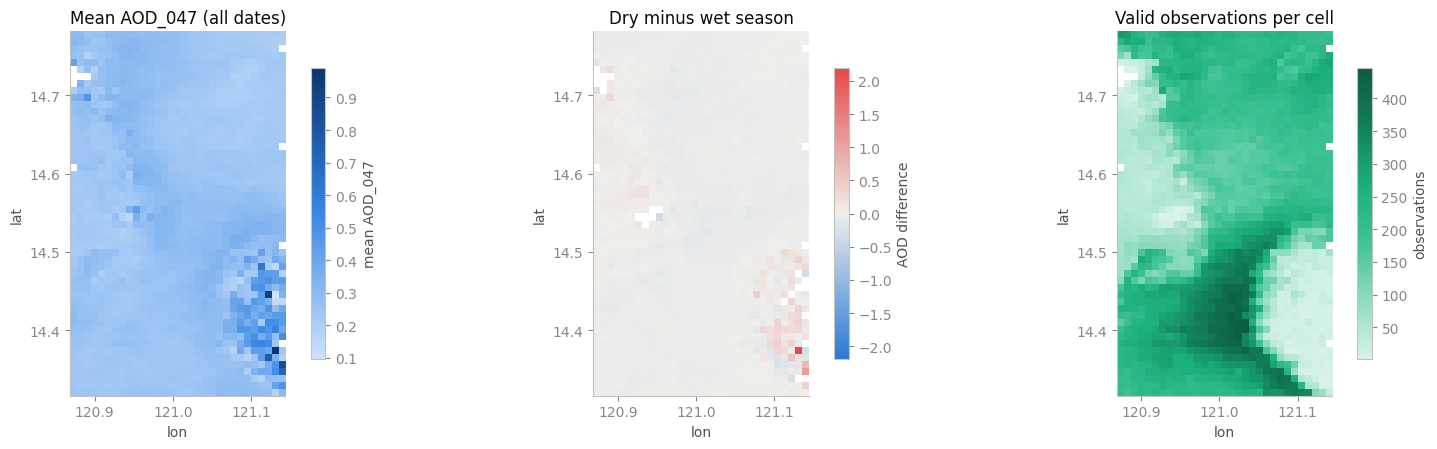

In [7]:
tot_sum, tot_cnt = aod_sum.sum(axis=0), aod_cnt.sum(axis=0)
mean_grid = np.where(tot_cnt > 0, tot_sum / np.maximum(tot_cnt, 1), np.nan)

def season_mean(month_list):
    idx = [m - 1 for m in month_list]
    s, c = aod_sum[idx].sum(axis=0), aod_cnt[idx].sum(axis=0)
    return np.where(c > 0, s / np.maximum(c, 1), np.nan)

diff = season_mean(DRY_MONTHS) - season_mean(WET_MONTHS)
dmax = np.nanmax(np.abs(diff))
extent = [AOI_BOUNDS[0], AOI_BOUNDS[2], AOI_BOUNDS[1], AOI_BOUNDS[3]]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
panels = [
    (mean_grid, SEQ_BLUE, "Mean AOD_047 (all dates)", dict(), "mean AOD_047"),
    (diff, DIV, "Dry minus wet season", dict(vmin=-dmax, vmax=dmax), "AOD difference"),
    (np.where(tot_cnt > 0, tot_cnt, np.nan), SEQ_AQUA, "Valid observations per cell", dict(), "observations"),
]
for ax, (g, cmap, title, kw, label) in zip(axes, panels):
    im = ax.imshow(g, cmap=cmap, extent=extent, origin="upper", **kw)
    fig.colorbar(im, ax=ax, shrink=0.8, label=label)
    ax.set_title(title)
    ax.set_xlabel("lon"); ax.set_ylabel("lat"); ax.grid(False)
plt.tight_layout(); plt.show()

## 7. Why do we lose pixels?

Decoded from the QA band with the same bit convention `modis.py` uses
(bits 0-1 = cloud, bit 2 = adjacent cloud, 65535 = fill/no retrieval).
Percentages are over all in-AOI pixels across all files. Note "kept" means
*passed the cloud mask* — the AOD retrieval itself can still be empty there,
so kept is an upper bound on usable coverage. This is the quantified version
of the "non-retrieval due to cloud cover" limitation cited in Chapter 1.

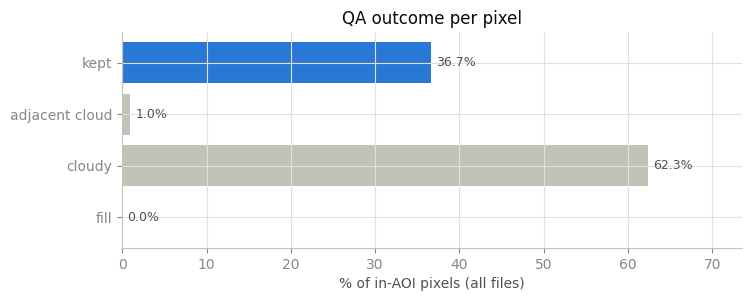

In [8]:
total = sum(qa_counts.values())
cats = ["kept", "adjacent cloud", "cloudy", "fill"]
fracs = [qa_counts[c] / total * 100 for c in cats]
colors = [C["AOD_047"], C["baseline"], C["baseline"], C["baseline"]]

fig, ax = plt.subplots(figsize=(8, 2.8))
bars = ax.barh(cats[::-1], fracs[::-1], color=colors[::-1])
for b, f in zip(bars, fracs[::-1]):
    ax.text(b.get_width() + 0.6, b.get_y() + b.get_height() / 2, f"{f:.1f}%",
            va="center", color=C["ink2"], fontsize=9)
ax.set_xlabel("% of in-AOI pixels (all files)")
ax.set_title("QA outcome per pixel")
ax.set_xlim(0, max(fracs) * 1.18)
plt.show()

## 8. AOD and water vapour — the humidity caveat

Section 3.3 of the thesis notes that humidity weakens the AOD-PM relationship:
wet aerosols swell and scatter more light (raising AOD) without adding dry PM
mass. The CWV band is a free humidity proxy that ships in every granule. A
strong positive correlation below would mean part of the AOD signal is water,
not particles — evidence for keeping humidity variables next to AOD in the
model, exactly as the pipeline already does.

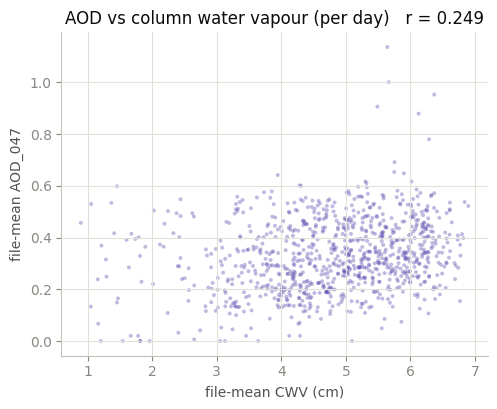

In [9]:
cwv_x = np.asarray(cwv_x); cwv_y = np.asarray(cwv_y)
r = np.corrcoef(cwv_x, cwv_y)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.scatter(cwv_x, cwv_y, s=8, alpha=0.35, color=C["CWV"], edgecolors="none")
ax.set_xlabel("file-mean CWV (cm)")
ax.set_ylabel("file-mean AOD_047")
ax.set_title(f"AOD vs column water vapour (per day)   r = {r:.3f}")
plt.show()

## 9. Fact sheet for the thesis

The numbers below fill the "to be confirmed" placeholders in Table 4.1 /
Section 4.2.6 and the wet/dry retrieval-rate reporting required by §4.3.7.
Copy them once the final production backfill has run.

In [10]:
print("=" * 62)
print("MODIS MCD19A2 (tile h29v07, Metro Manila AOI) - fact sheet")
print("=" * 62)
print(f"Granules processed:            {len(df)}")
print(f"Coverage window:               {start:%Y-%m-%d} to {end:%Y-%m-%d}")
print(f"Days with a granule:           {len(have_days)} / {len(all_days)} ({len(have_days)/len(all_days):.0%})")
print(f"Days with any valid AOD:       {len(valid_dates)} ({len(valid_dates)/len(all_days):.0%})")
print(f"Valid pixels (AOD_047):        {pools['AOD_047'].size:,}")
print()
print("Valid-retrieval rate (fraction of cell-days with usable AOD):")
print(f"  overall                      {overall_rate:.1f}%")
print(f"  dry season (Dec-May)         {dry_rate:.1f}%")
print(f"  wet season (Jun-Nov)         {wet_rate:.1f}%")
print()
print(f"Median revisit gap:            {gaps.median():.0f} day(s)")
print(f"Longest blackout:              {gaps.max():.0f} days (ending {worst_end:%Y-%m-%d})")
print(f"QA kept / cloudy / adj / fill: "
      f"{qa_counts['kept']/total:.1%} / {qa_counts['cloudy']/total:.1%} / "
      f"{qa_counts['adjacent cloud']/total:.1%} / {qa_counts['fill']/total:.1%}")
print()
print(f"AOD_047 pixel stats:           mean {pools['AOD_047'].mean():.3f}, "
      f"median {np.median(pools['AOD_047']):.3f}, p95 {np.percentile(pools['AOD_047'], 95):.3f}")
print(f"AOD_047 vs AOD_055:            r = {np.corrcoef(pair_x, pair_y)[0, 1]:.3f}")
print("=" * 62)

MODIS MCD19A2 (tile h29v07, Metro Manila AOI) - fact sheet
Granules processed:            980
Coverage window:               2021-07-12 to 2026-07-08
Days with a granule:           980 / 1823 (54%)
Days with any valid AOD:       944 (52%)
Valid pixels (AOD_047):        325,731

Valid-retrieval rate (fraction of cell-days with usable AOD):
  overall                      10.0%
  dry season (Dec-May)         14.9%
  wet season (Jun-Nov)         5.1%

Median revisit gap:            1 day(s)
Longest blackout:              17 days (ending 2025-07-29)
QA kept / cloudy / adj / fill: 36.7% / 62.3% / 1.0% / 0.0%

AOD_047 pixel stats:           mean 0.258, median 0.237, p95 0.507
AOD_047 vs AOD_055:            r = 0.996


## Takeaways

- **The satellite covariate is sparse by nature** — the retrieval rate above is
  the concrete number behind that statement, and the wet-season drop is the
  monsoon cost the thesis anticipates. On every missing cell-day the pipeline
  falls back to the kriged surface, so kriging quality matters most exactly
  when clouds (and rain) dominate.
- **When AOD is present it is well behaved**: the two AOD bands agree almost
  perfectly, values sit in a plausible urban range, and there is a real spatial
  gradient inside the AOI — the justification for using it at all.
- **Missingness is seasonal, not random**, which is why the thesis treats its
  effect on downscaling as an empirical question rather than assuming it away.
- If "days with a granule" is well below 100%, re-run the backfill before the
  production dataset is frozen — some of the gap is downloadable, not cloud.